<a href="https://colab.research.google.com/github/sgrouplabs/HW/blob/main/603Task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
#D3

import pandas as pd

# Load the dataset
df = pd.read_csv('churn_clean.csv')

selected_cols = ['Tenure', 'MonthlyCharge', 'Bandwidth_GB_Year',
                 'Contract', 'InternetService', 'TechSupport', 'Churn']
df_selected = df[selected_cols].copy()

In [7]:
# Convert Churn to 1 (Yes) and 0 (No)
df_selected['Churn'] = df_selected['Churn'].map({'Yes': 1, 'No': 0})

In [8]:
# One-Hot Encode categorical variables
df_clean = pd.get_dummies(df_selected, columns=['Contract', 'InternetService', 'TechSupport'], drop_first=True)

print(df_clean.head())

      Tenure  MonthlyCharge  Bandwidth_GB_Year  Churn  Contract_One year  \
0   6.795513     172.455519         904.536110      0               True   
1   1.156681     242.632554         800.982766      1              False   
2  15.754144     159.947583        2054.706961      0              False   
3  17.087227     119.956840        2164.579412      0              False   
4   1.670972     149.948316         271.493436      1              False   

   Contract_Two Year  InternetService_Fiber Optic  TechSupport_Yes  
0              False                         True            False  
1              False                         True            False  
2               True                        False            False  
3               True                        False            False  
4              False                         True             True  


In [9]:
# Export to a new CSV file
df_clean.to_csv('churn_prepared_for_RF.csv', index=False)

In [10]:
# E1

import pandas as pd
from sklearn.model_selection import train_test_split

# Separate the features (X) from the target variable (y)
X = df_clean.drop('Churn', axis=1)
y = df_clean['Churn']

# First Split: 70% Training, 30% Temporary (Validation + Test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# Second Split: Divide the 30% Temporary set into 15% Validation and 15% Test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

# Combine X and y back together for exporting
train_data = pd.concat([X_train, y_train], axis=1)
val_data = pd.concat([X_val, y_val], axis=1)
test_data = pd.concat([X_test, y_test], axis=1)

# Export the datasets to CSV files
train_data.to_csv('churn_train_data.csv', index=False)
val_data.to_csv('churn_val_data.csv', index=False)
test_data.to_csv('churn_test_data.csv', index=False)

print(f"Training Data: {train_data.shape[0]} rows")
print(f"Validation Data: {val_data.shape[0]} rows")
print(f"Test Data: {test_data.shape[0]} rows")

Training Data: 7000 rows
Validation Data: 1500 rows
Test Data: 1500 rows


--- Initial Random Forest Model Metrics ---
Accuracy:  0.8913
Precision: 0.8005
Recall:    0.7864
F1 Score:  0.7934
AUC-ROC:   0.9460


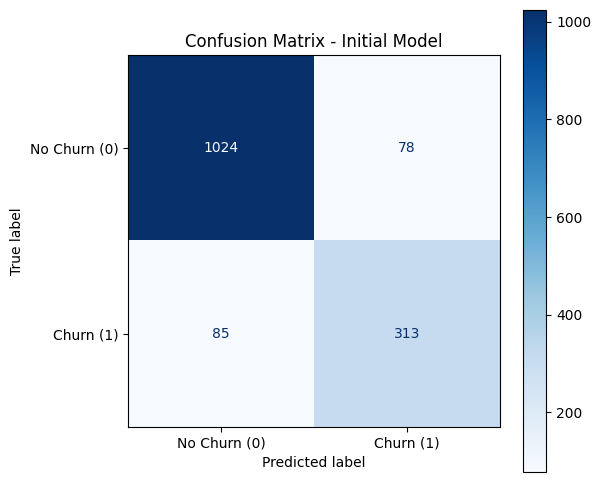

In [11]:
#E2 Creating Model

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)

# Train (fit) the model using the training dataset
rf_model.fit(X_train, y_train)

# Make predictions on the Validation dataset
y_pred = rf_model.predict(X_val)
y_pred_proba = rf_model.predict_proba(X_val)[:, 1] # Probabilities needed for AUC-ROC

# Calculate Metrics
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
auc_roc = roc_auc_score(y_val, y_pred_proba)

# Print metrics
print("--- Initial Random Forest Model Metrics ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc_roc:.4f}")

# Generate and plot the Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn (0)', 'Churn (1)'])

# Plotting the matrix
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix - Initial Model')
plt.show()

In [12]:
#E3 Tuning

from sklearn.model_selection import GridSearchCV

# Grid of hyperparameters to test
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

# Initialize the Grid Search with 5-fold cross-validation
# n_jobs=-1 to use all available processor cores and speed up the search
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           n_jobs=-1)

# Perform tuning on the validation dataset (as requested)
grid_search.fit(X_val, y_val)

# Output the best hyperparameters
print("--- Best Hyperparameters Found ---")
print(grid_search.best_params_)

--- Best Hyperparameters Found ---
{'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 50}


--- Final Optimized Model Metrics (Test Dataset) ---
Accuracy:  0.9047
Precision: 0.8307
Recall:    0.8035
F1 Score:  0.8169
AUC-ROC:   0.9524


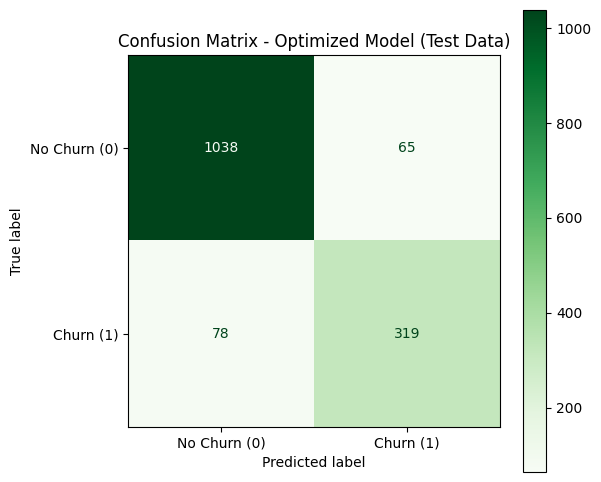

In [13]:
#E4 Optimization

# Extract the best model from the grid search
optimized_rf = grid_search.best_estimator_

# Retrain the optimized model on the primary training dataset
optimized_rf.fit(X_train, y_train)

# Make predictions on the unseen TEST dataset
y_pred_test = optimized_rf.predict(X_test)
y_pred_proba_test = optimized_rf.predict_proba(X_test)[:, 1]

# Calculate Final Metrics
accuracy_test = accuracy_score(y_test, y_pred_test)
precision_test = precision_score(y_test, y_pred_test)
recall_test = recall_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)
auc_roc_test = roc_auc_score(y_test, y_pred_proba_test)

# Print metrics
print("--- Final Optimized Model Metrics (Test Dataset) ---")
print(f"Accuracy:  {accuracy_test:.4f}")
print(f"Precision: {precision_test:.4f}")
print(f"Recall:    {recall_test:.4f}")
print(f"F1 Score:  {f1_test:.4f}")
print(f"AUC-ROC:   {auc_roc_test:.4f}")

# Generate and plot the Final Confusion Matrix
cm_test = confusion_matrix(y_test, y_pred_test)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['No Churn (0)', 'Churn (1)'])

# Plotting the matrix
fig, ax = plt.subplots(figsize=(6, 6))
disp_test.plot(cmap='Greens', ax=ax, values_format='d')
plt.title('Confusion Matrix - Optimized Model (Test Data)')
plt.show()